# **Modelos secuenciales: LSTM inter-época e híbrido CNN1D $\to$ BiLSTM**

Este cuaderno entrena y compara los **dos modelos secuenciales** del proyecto con **una sola función** (`src.lstm.train`) y el **mismo split por sujeto**, para que sus métricas sean directamente comparables:

1. **LSTM tabular** (`hybrid=False`): una BiLSTM many-to-many sobre la secuencia de **features handcrafted** por época (`epoch_features.csv`). El encoder intra-época es `IdentityEncoder` (pasa las features tal cual). Modela la **dinámica inter-época**.
2. **Híbrido CNN1D $\to$ BiLSTM** (`hybrid=True`): una **CNN 1D** (`CNNEpochEncoder`) resume la **señal cruda** de cada época (`sequences/*.npz`, `[150, 4]`) en un vector, y la BiLSTM lee esa secuencia. Se entrena **end-to-end** (una sola loss ajusta CNN y LSTM juntas). Combina morfología **intra-época** y dinámica **inter-época**.

## Arquitectura común
$$\text{época}[\dots] \;\xrightarrow{\text{encoder}}\; [T, F_{enc}] \;\xrightarrow{\text{BiLSTM (2 capas)}}\; \text{Dropout} \to \text{Linear} \to \text{logits}[T, 5]$$

- **encoder**: `IdentityEncoder` (tabular, $F_{enc}=122$) o `CNNEpochEncoder` (híbrido, $F_{enc}=128$). Es el único punto que cambia entre modos.
- **BiLSTM**: `hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True`. Lee la noche hacia adelante y hacia atrás (sleep staging offline → sin restricción de causalidad).
- **Padding + packing**: las noches tienen largo variable; `collate_nights` paddea al máximo del batch (features con 0.0, labels con `UNKNOWN=5`) y `pack_padded_sequence` hace que la LSTM ignore el relleno. La loss usa `ignore_index=UNKNOWN` (Unknown + padding fuera de la loss y de las métricas).
- **Loss**: `CrossEntropyLoss` con **pesos de clase** inversos a la frecuencia (desbalance N2 ≫ N1) + **gradient clipping**.

## Split y comparabilidad
El split es **por sujeto** (`partition_subjects`, sujetos disjuntos train/val/test), con la **misma seed y fracciones** para los dos modelos $\implies$ **exactamente los mismos sujetos** en cada partición. Así la diferencia de Kappa entre LSTM e híbrido refleja el modelo, no la partición.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, glob
sys.path.append("..")

# import temprano de torch._dynamo: evita un fallo de sympy con kernel de estado sucio.
import torch
import torch._dynamo  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.lstm import ConfigLSTM, train, evaluate, plot_history, predict_night, STAGE_NAMES
from src.sequence_data import build_night_sequences
from src.feature_extraction import feature_extraction
from src.tuning import run_search, best_config
from src.plots import night_prediction_overview
from src.metrics import print_metrics, plot_confusion, roc_pr_curves

## 1. Datos (se generan solo si faltan)

- **`epoch_features.csv`** (modo tabular): lo produce `baseline.ipynb` (feature extraction). Si no existe, se genera acá.
- **`sequences/*.npz`** (modo híbrido): señal cruda por noche + `night_id`.

Ambos derivan de los mismos pacientes, así que el split por sujeto coincide entre modos.

In [ ]:
FEATURES = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES):
    print(f"{FEATURES} ya existe; se omite la extracción.")
else:
    feature_extraction()

SEQ_DIR = "../data_extraction/sequences"
if glob.glob(os.path.join(SEQ_DIR, "*.npz")):
    print(f"{SEQ_DIR} ya tiene datos; se omite el procesamiento.")
else:
    build_night_sequences(output_dir=SEQ_DIR)

## 2. Configuración y split compartido

Dos `ConfigLSTM` que difieren solo en el modo (`hybrid`) y el checkpoint. La **misma seed** garantiza el **mismo split por sujeto** para los dos. `TRAIN_NEW` es la constante universal entrenar-de-cero / usar-guardado.

In [3]:
TRAIN_NEW = True  # True: entrena de cero y sobreescribe el checkpoint; False: usa el .pt guardado

# configuraciones default
cfg_lstm = ConfigLSTM(hybrid=False, ckpt_path="../models/best_lstm.pt",
                      epochs=60, patience=10)
cfg_hyb = ConfigLSTM(hybrid=True,  ckpt_path="../models/best_hybrid.pt",
                      hidden_size=128, num_layers=2, dropout=0.3, bidirectional=True,
                      batch_size=8, lr=1e-3, epochs=120, patience=20, use_class_weights=True)

## 2.5 Búsqueda bayesiana de hiperparámetros (Optuna)

Antes de entrenar los modelos "finales" buscamos buenos hiperparámetros con **búsqueda bayesiana** en lugar de probar a mano o hacer *grid search*.

**¿Qué es?** El *grid/random search* prueba configuraciones **a ciegas**. La búsqueda bayesiana construye un **modelo probabilístico** de la relación *hiperparámetros $\to$ métrica* y, a partir de los trials ya evaluados, propone la **siguiente configuración más prometedora** (equilibrando explorar zonas nuevas y explotar las que rindieron bien). Así llega a buenas configuraciones con **muchos menos entrenamientos**.

**Cómo lo hacemos (`src/tuning.py`, con [Optuna](https://optuna.org/)):**
- El sampler **TPE** (*Tree-structured Parzen Estimator*) implementa la parte bayesiana.
- **Objetivo a maximizar: el Cohen's Kappa del set de _validación_**. Se toma el kappa del mejor epoch, igual criterio con que `train` guarda el checkpoint.
- Espacio de búsqueda (`default_space`): `hidden_size`, `num_layers`, `dropout`, `lr`, `weight_decay`, `batch_size` (+ `feature_dim` en el híbrido). El resto de la config (seed, fracciones del split, `hybrid`, paths) queda **fijo** ⇒ split por sujeto idéntico entre trials y entre modelos.
- **Se corren dos búsquedas independientes**, una por modelo.

**Costo y optimizaciones (clave en el híbrido).** El híbrido es mucho más pesado que el tabular: corre una CNN por época de cada noche (~24–27 s/epoch con `feature_dim=128`, más con 256), todo en GPU. Para que el search sea viable:
- **`search_epochs`**: cada trial entrena menos epochs que el entrenamiento final (acá 25 tabular / 15 híbrido). Basta para **rankear** configs; al ganador se lo re-entrena con todas las epochs vía `USE_BEST`.
- **MedianPruner**: corta un trial apenas su kappa de val cae por debajo de la mediana de los previos al mismo epoch. Los trials podados **no** se guardan en el CSV.
- **AMP (mixed precision)**: `train` usa `autocast`+`GradScaler` en GPU (flag `cfg.amp`, auto-on en cuda). Baja memoria; el extra de velocidad es modesto acá porque la LSTM casi no se acelera.

**Persistencia (para correr el search en varias instancias):** cada estudio se guarda en `models/searchs/<name>.db` (SQLite $\to$ **resume** donde quedó y el TPE aprovecha todo el historial) y en `models/searchs/<name>.csv`, un log legible con **toda la config** de cada trial + su `kappa/macro_f1/accuracy` de val. Cada corrida **agrega** sus trials nuevos (no reescribe) y deja el CSV **ordenado por kappa descendente**. `best_config(base_cfg, name)` levanta del CSV los mejores hiperparámetros sobre la config base (conservando `epochs`/paths de la base).

In [ ]:
RUN_SEARCH = True  # True: corre N_TRIALS de búsqueda bayesiana por modelo.
N_TRIALS = 5       # trials POR ejecución.

if RUN_SEARCH:
    run_search(cfg_lstm, name="lstm", n_trials=N_TRIALS, search_epochs=25)
    run_search(cfg_hyb, name="hybrid", n_trials=N_TRIALS, search_epochs=15)

In [5]:
USE_BEST = True  # True: reemplaza los hiperparámetros de las configuraciones por los mejores del search
			     # False: utiliza hiperparámetros de las configuraciones default

if USE_BEST:
    cfg_lstm = best_config(cfg_lstm, "lstm")
    cfg_hyb = best_config(cfg_hyb, "hybrid")
    print("cfg_lstm ->", cfg_lstm)
    print("cfg_hyb  ->", cfg_hyb)

cfg_lstm -> ConfigLSTM(hybrid=False, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=128, hidden_size=128, num_layers=3, dropout=0.3416493362665036, bidirectional=True, batch_size=4, lr=0.0018273545014266, weight_decay=0.0001339959719863, epochs=60, grad_clip=5.0, use_class_weights=True, amp=None, patience=10, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../models/best_lstm.pt', feature_cols=None, input_size=None)
cfg_hyb  -> ConfigLSTM(hybrid=True, features_path='../data_extraction/epoch_features.csv', sequences_dir='../data_extraction/sequences', feature_dim=256, hidden_size=128, num_layers=3, dropout=0.4366107897120125, bidirectional=True, batch_size=8, lr=0.0005811604803142, weight_decay=4.078835816332079e-05, epochs=120, grad_clip=5.0, use_class_weights=True, amp=None, patience=20, val_frac=0.15, test_frac=0.15, seed=36631, device='cuda', ckpt_path='../models/best_hybrid.pt', feature_cols=None

## 3. LSTM tabular (inter-época)

BiLSTM sobre las 122 features handcrafted ([epoch_features.csv](data_extraction/epoch_features.csv)).

In [6]:
if TRAIN_NEW or not os.path.exists(cfg_lstm.ckpt_path):
    model_lstm, hist_lstm, test_lstm = train(cfg_lstm)
else:
    model_lstm, test_lstm = evaluate(cfg_lstm)
    hist_lstm = None

Early Stop (LSTM) - epoch 25 (mejor 0.4654 @ 15):  40%|████      | 24/60 [07:09<10:44, 17.91s/epoch, train_loss=0.7582, val_loss=1.1217, val_kappa=0.4491, best=0.4654]



TEST (LSTM) — mejor ckpt (val kappa 0.4654, epoch 15):
  kappa 0.4503 | macroF1 0.5582 | acc 0.5727
  4-clases: kappa 0.4754 | macroF1 0.6417 | acc 0.6282


## 4. Híbrido CNN1D $\to$ BiLSTM

La misma `train`, con `hybrid=True`: el `CNNEpochEncoder` (GroupNorm, robusto al padding) resume cada época de señal cruda `[150, 4]` en 128 features y la BiLSTM lee la secuencia. Más lento (la CNN corre sobre todas las épocas de cada noche); conviene GPU.

In [7]:
if TRAIN_NEW or not os.path.exists(cfg_hyb.ckpt_path):
    model_hyb, hist_hyb, test_hyb = train(cfg_hyb)
else:
    model_hyb, test_hyb = evaluate(cfg_hyb)
    hist_hyb = None

Early Stop (Hybrid) - epoch 102 (mejor 0.4033 @ 82):  84%|████████▍ | 101/120 [1:15:57<14:17, 45.12s/epoch, train_loss=0.6509, val_loss=1.4437, val_kappa=0.3621, best=0.4033]



TEST (Hybrid) — mejor ckpt (val kappa 0.4033, epoch 82):
  kappa 0.3442 | macroF1 0.4696 | acc 0.4756
  4-clases: kappa 0.3672 | macroF1 0.5492 | acc 0.5497


## 5. Curvas de entrenamiento (train vs validación)

Para cada modelo: (izq) loss de **train vs validación** por epoch - si divergen, sobreajuste; (der) métricas de **validación** (kappa/macro-F1/accuracy) que muestran en qué epoch quedó el mejor checkpoint.

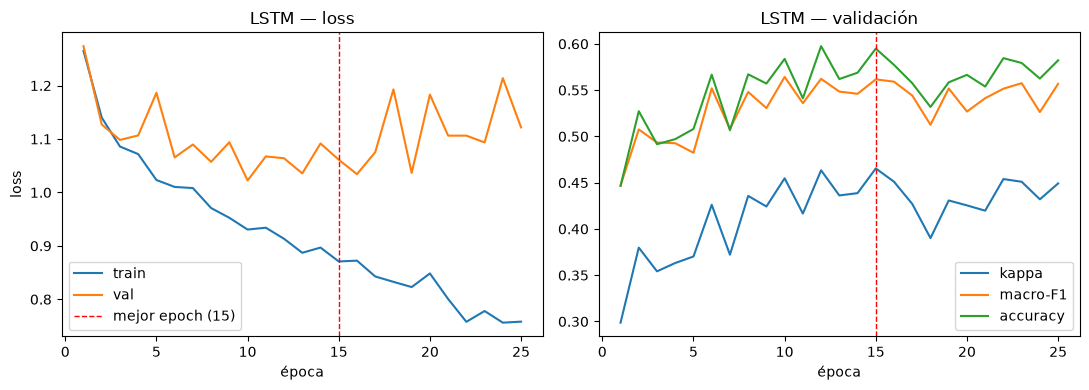

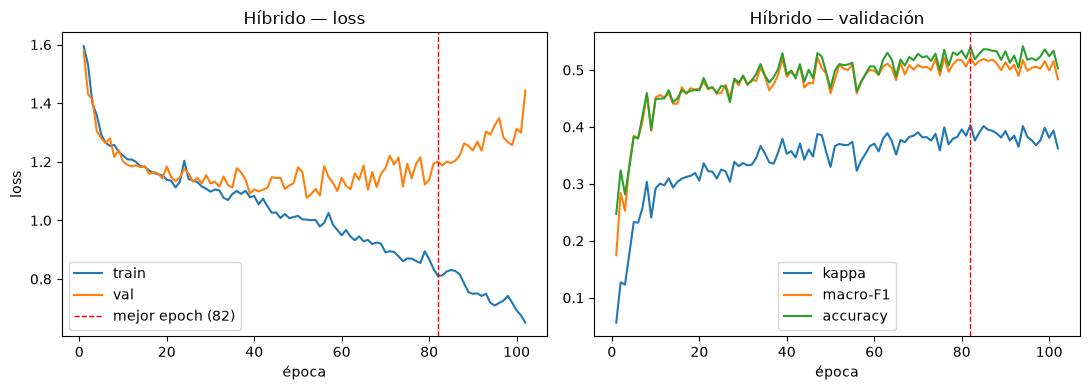

In [8]:
for name, hist in [('LSTM', hist_lstm), ('Híbrido', hist_hyb)]:
    if hist is None:
        print(f"{name}: sin history (TRAIN_NEW=False); se omiten las curvas.")
    else:
        plot_history(hist, title=name)
        plt.tight_layout(); plt.show()

## 6. Comparación en test (mismo split)

Métricas de test de los dos modelos, calculadas sobre el **mismo test set por sujeto**: Cohen's Kappa (principal), macro-F1 y accuracy, en 5 clases y en la vista colapsada a 4 (Wake / Light=N1+N2 / Deep=N3 / REM). Debajo, para cada modelo, el desglose por clase (`print_metrics`), la matriz de confusión (`plot_confusion`) y las curvas ROC/PR one-vs-rest (`roc_pr_curves`) — todo desde `src/metrics.py`, las mismas funciones que usan los demás notebooks.

In [ ]:
rows = []
for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    rows.append({'modelo': name, 'kappa': tm['kappa'], 'macro_f1': tm['macro_f1'],
                 'accuracy': tm['accuracy'], 'kappa_4': tm['kappa_4'],
                 'macro_f1_4': tm['macro_f1_4'], 'accuracy_4': tm['accuracy_4']})
summary = pd.DataFrame(rows).set_index('modelo').round(4)
print("Test (mismo split por sujeto, vs Expert):")
print(summary.to_string())

# desglose por clase, matriz de confusión y curvas ROC/PR de cada modelo (src.metrics)
for name, tm in [('LSTM tabular', test_lstm), ('Híbrido', test_hyb)]:
    print_metrics(tm['y_true'], tm['y_pred'], name=f'\n{name} (test, vs Expert):')
    plot_confusion(tm['y_true'], tm['y_pred'], title=f'Matriz de confusión — {name} (test)')
    plt.show()
    roc_pr_curves(tm['y_true'], tm['y_score'], title=f'{name} — ROC y PR por clase (test, vs Expert)')
    plt.show()

## 7. Overview de una noche con las predicciones

Como el `night_overview` del EDA, pero agregando debajo de las señales los **hipnogramas** de Expert, Dreem y las predicciones de **ambos modelos** (LSTM tabular e híbrido), alineados por índice de época. Permite ver *dónde* acierta o falla cada modelo a lo largo de la noche (típicamente en las transiciones y en N1).

In [ ]:
# una noche del test set (sujetos de test del split compartido, guardados en el checkpoint)
ckpt = torch.load(cfg_lstm.ckpt_path, map_location='cpu', weights_only=False)
subject = sorted(ckpt['subj']['test'])[1]
night = int(pd.read_csv(cfg_lstm.features_path).query('subject == @subject')['night'].min())

preds = {'BiLSTM': predict_night(model_lstm, cfg_lstm, subject, night)}
try:
    preds['Hybrid'] = predict_night(model_hyb, cfg_hyb, subject, night)
except KeyError as e:
    print(f"fila híbrido omitida: {e}")

night_prediction_overview(subject, night, preds)